In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import DBSCAN

In [2]:
bronx_matched = pd.read_csv('../data/processed/bronx_matched_clean.csv')
bronx_matched['crash_date'] = pd.to_datetime(bronx_matched['crash_date'])

In [3]:
bronx_matched.info()
bronx_matched.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225012 entries, 0 to 225011
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   collision_id                   225012 non-null  int64         
 1   crash_date                     225012 non-null  datetime64[ns]
 2   crash_time                     225012 non-null  object        
 3   on_street_name                 162979 non-null  object        
 4   cross_street_name              61645 non-null   object        
 5   latitude                       225012 non-null  float64       
 6   longitude                      225012 non-null  float64       
 7   number_of_persons_injured      225012 non-null  float64       
 8   number_of_persons_killed       225012 non-null  float64       
 9   contributing_factor_vehicle_1  223846 non-null  object        
 10  crash_year                     225012 non-null  int64         
 11  

,collision_id,crash_date,crash_time,on_street_name,cross_street_name,latitude,longitude,number_of_persons_injured,number_of_persons_killed,contributing_factor_vehicle_1,crash_year,crash_month,crash_dayofweek,crash_hour,contributing_factor_grouped
0,72589,2012-07-01,20:30,CAULDWELL AVENUE,NaN,40.821167,-73.907749,0.0,0.0,Driver Inattention/Distraction,2012,7,Sunday,20,Driver Inattention/Distraction
1,72590,2012-07-01,18:40,WILLOW AVENUE,NaN,40.801665,-73.913223,0.0,0.0,Illness,2012,7,Sunday,18,Other
2,72591,2012-07-01,19:35,EAST 149 STREET,NaN,40.816081,-73.917687,0.0,0.0,Other Electronic Device,2012,7,Sunday,19,Other
3,72593,2012-07-02,11:10,EAST 149 STREET,NaN,40.813233,-73.909075,1.0,0.0,Driver Inattention/Distraction,2012,7,Monday,11,Driver Inattention/Distraction
4,72595,2012-07-02,17:30,BRUCKNER BOULEVARD,NaN,40.804696,-73.922386,0.0,0.0,Fatigued/Drowsy,2012,7,Monday,17,Other


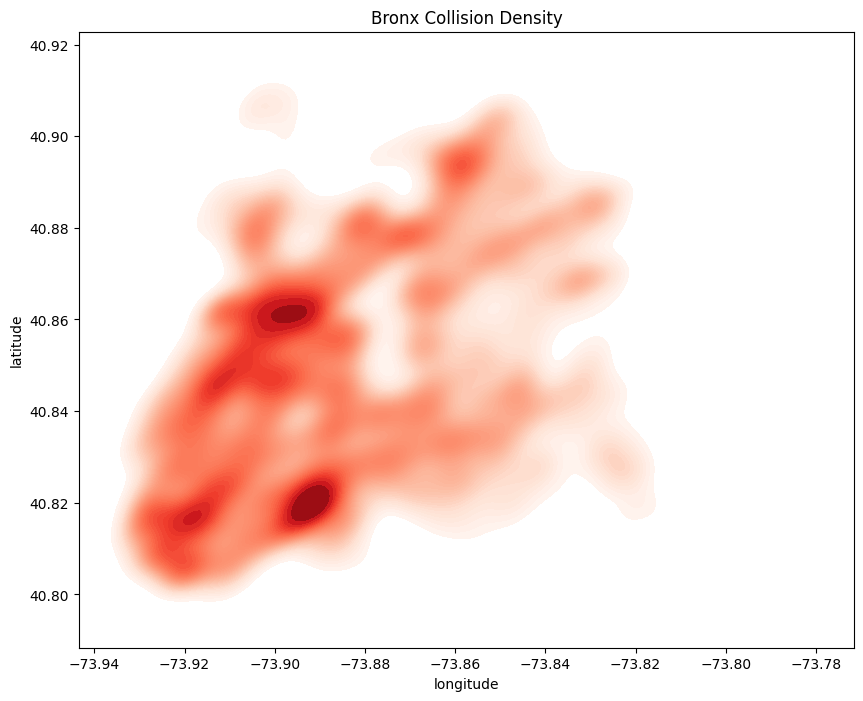

In [4]:
plt.figure(figsize=(10, 8))
sns.kdeplot(
    data=bronx_matched,
    x='longitude',
    y='latitude',
    cmap='Reds',
    fill=True,
    thresh=0.05,
    levels=50
)
plt.title('Bronx Collision Density')
plt.show()

In [6]:
geometry = [Point(xy) for xy in zip(bronx_matched['longitude'], bronx_matched['latitude'])]
bronx_geo = gpd.GeoDataFrame(bronx_matched, geometry=geometry, crs="EPSG:4326")

bronx_projected = bronx_geo.to_crs(epsg=32618)

bronx_matched['x_m'] = bronx_projected.geometry.x
bronx_matched['y_m'] = bronx_projected.geometry.y

In [7]:
bronx_matched[['x_m', 'y_m']].head()

,x_m,y_m
0,592108.655801,4.519479e+06
1,591673.888281,4.517309e+06
2,591277.508611,4.518904e+06
3,592007.796045,4.518597e+06
4,590896.745056,4.517635e+06


In [34]:
coords = bronx_matched[['x_m', 'y_m']]

db = DBSCAN(eps=20, min_samples=10)
bronx_matched['cluster'] = db.fit_predict(coords)

bronx_matched[bronx_matched['cluster'] != -1]['cluster'].value_counts().describe()

count    4465.000000
mean       42.272340
std        55.963427
min         1.000000
25%        15.000000
50%        26.000000
75%        46.000000
max      1027.000000
Name: count, dtype: float64

In [35]:
print(bronx_matched['cluster'].nunique())          #clusters found
print((bronx_matched['cluster'] == -1).sum())      #noise #

4466
36266


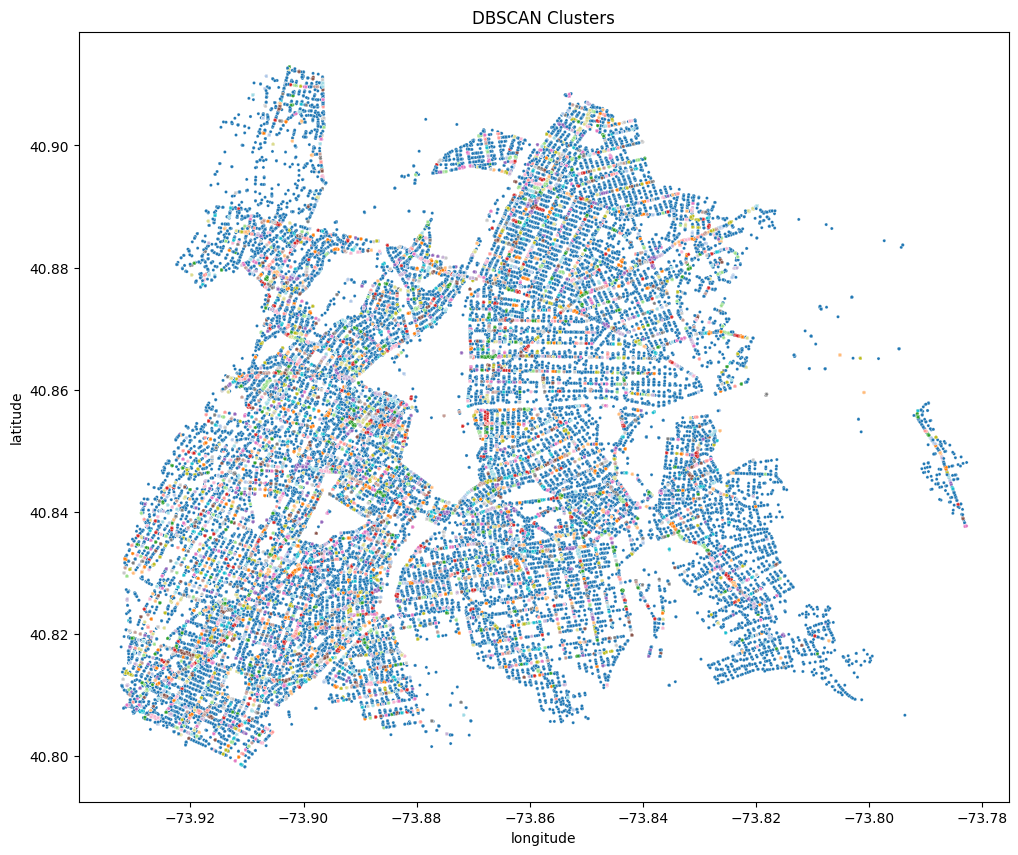

In [36]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=bronx_matched,
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='tab20',
    s=5,
    legend=False
)
plt.title('DBSCAN Clusters')
plt.show()

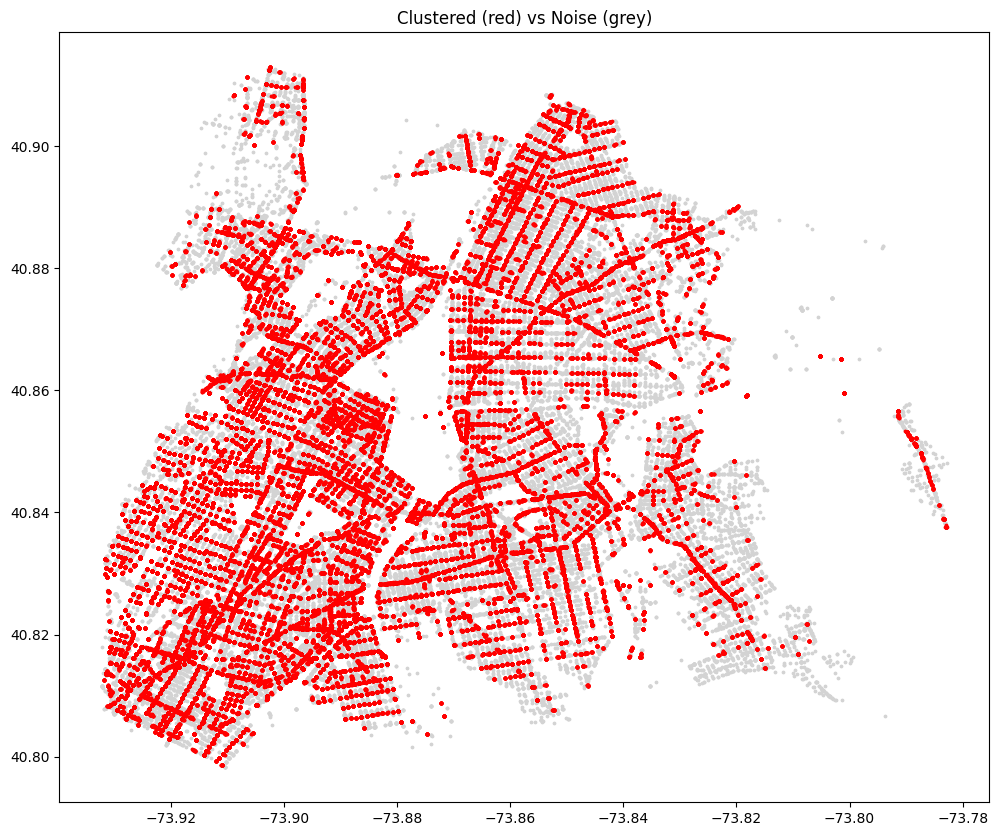

In [37]:
noise = bronx_matched[bronx_matched['cluster'] == -1]
clustered = bronx_matched[bronx_matched['cluster'] != -1]

plt.figure(figsize=(12, 10))
plt.scatter(noise['longitude'], noise['latitude'], color='lightgrey', s=3)
plt.scatter(clustered['longitude'], clustered['latitude'], color='red', s=3)
plt.title('Clustered (red) vs Noise (grey)')
plt.show()

In [38]:
biggest['latitude'].value_counts().head(10)

latitude
40.861862    665
40.861864    277
40.861866     81
40.861916      4
Name: count, dtype: int64

In [46]:
cluster_summary = bronx_matched[bronx_matched['cluster'] != -1].groupby('cluster').agg(
    crash_count=('collision_id', 'count'),
    center_lat=('latitude', 'mean'),
    center_lon=('longitude', 'mean'),
    top_street=('on_street_name', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()

cluster_summary.sort_values('crash_count', ascending=False).head(20)

,cluster,crash_count,center_lat,center_lon,top_street
3216,3216,1027,40.861863,-73.912780,WEST FORDHAM ROAD
317,317,989,40.820234,-73.890738,BRUCKNER BOULEVARD
1928,1928,663,40.878309,-73.870150,EAST GUN HILL ROAD
1934,1934,531,40.878644,-73.871601,EAST GUN HILL ROAD
1908,1908,511,40.895384,-73.863554,EAST 233 STREET
330,330,489,40.813119,-73.898318,BRUCKNER BOULEVARD
315,315,488,40.815791,-73.895346,BRUCKNER BOULEVARD
1768,1768,488,40.861696,-73.891379,EAST FORDHAM ROAD
1687,1687,476,40.847590,-73.900608,EAST TREMONT AVENUE
2452,2452,473,40.846682,-73.896292,EAST TREMONT AVENUE


In [47]:
cluster_summary.to_csv('../data/processed/bronx_cluster_summary.csv', index=False)